# TeNNet-SAC Demonstration Notebook

This notebook demonstrates how to use the TeNNet-SAC framework to:

- Predict **σ-profiles** and molecular geometry from SMILES strings  
- Predict **activity coefficients** for both binary and multicomponent mixtures  
  - You can choose between the **Base model** (trained on COSMO-SAC data) and the **Fine-tuned model** (refined with experimental data)

## Import

In [1]:
import numpy as np

from tennetsac import binary_lng, multi_lng, profile


## Public API

In [ ]:
# Models are initialized lazily on the first prediction call.
# The packaged checkpoints are resolved by tennetsac; no repository paths are needed.

# σ-Profile Prediction

**Input:**  
`smiles`: A single SMILES string

**Output:**  
- Surface area (Å²)  
- Molecular volume (Å³)  
- σ-profile plot

Surface Area    : 154.17 Å²
Molecular Volume: 139.42 Å³


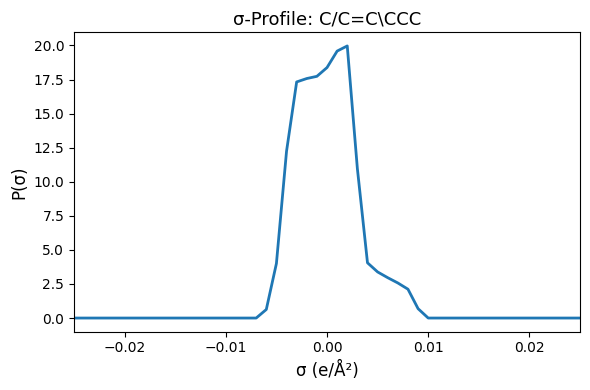

In [3]:
# ==== Input ====
smiles = 'C/C=C\CCC'
# ================

prf, area, volume = profile(smiles)
print(f"Surface Area    : {area:.2f} Å²")
print(f"Molecular Volume: {volume:.2f} Å³")
# `prf` contains the predicted sigma-profile values.

# Activity Coefficient Prediction

### Choose Model

Select which model to use for predicting activity coefficients:

1. The **Base model** (trained on COSMO-SAC data)
2. The **Fine-tuned model** (refined with experimental data)

Use `"base"` or `"tuned"` as the `model_type` argument below.


In [4]:
model_version = "tuned"  # Use "base" for the COSMO-SAC-pretrained model.

## Binary System

Define the input for binary mixture prediction:

- `smiles_1`: SMILES of component 1  
- `smiles_2`: SMILES of component 2  
- `temperature`: Temperature in Kelvin 
- `x1_list`: Mole fraction list for component 1 (from 0 to 1)

The mole fraction of component 2 will be automatically set as `1 − x₁`.

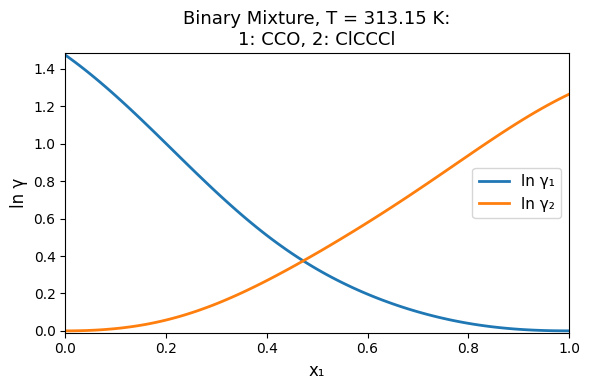

CCO
  Surface Area    : 89.52 Å²
  Molecular Volume: 70.53 Å³
ClCCCl
  Surface Area    : 118.42 Å²
  Molecular Volume: 102.63 Å³


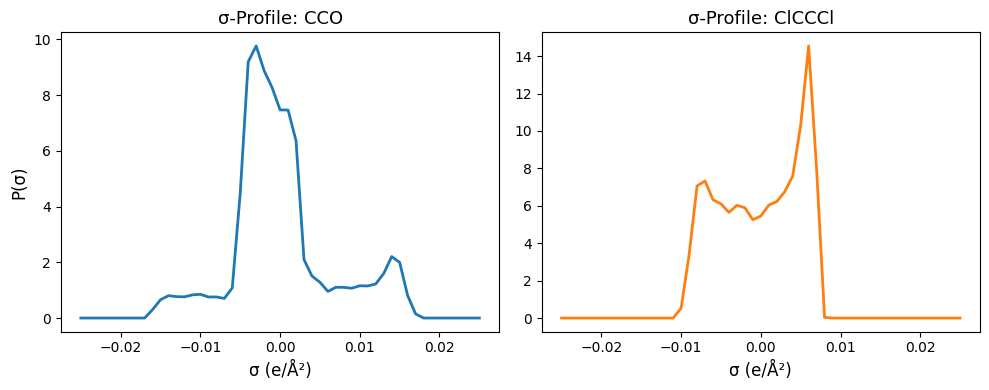

In [5]:
# ==== Input ====
smiles_1 = "CCO"
smiles_2 = "ClCCCl"
temperature = 313.15  # K
x1_list = np.linspace(0.0, 1.0, 101)
# ================

ln_gamma_1, ln_gamma_2 = binary_lng(
    [smiles_1, smiles_2], temperature, x1_list.tolist(), version=model_version
)

print(ln_gamma_1)
print(ln_gamma_2)


## Multicomponent System

Define the input for a multicomponent mixture:

- `smiles_list`: List of SMILES strings for all *n* components  
- `mole_fraction_list`: Mole fractions for all *n* components; they must sum to 1  
- `temperature`: Temperature in Kelvin  

The model will predict the activity coefficients (`ln γ`) for each component.


In [ ]:
# ==== Input ====
smiles_list = ['CO', 'CCCc1ccccc1C', 'C/C=C\C', 'O'] # len = n
mole_fraction_list = [0.3, 0.4, 0.1, 0.2] # len = n
temperature = 298.15  # K
# ================

ln_gamma = multi_lng(
    smiles_list,
    mole_fraction_list,
    temperature,
    version=model_version
)

print(ln_gamma)


=== ln γ at T = 298.15 K ===


,SMILES,Mole Fraction,ln γ
0,CO,0.3,0.1790
1,CCCc1ccccc1C,0.4,1.3212
2,C/C=C\C,0.1,0.9149
3,O,0.2,2.3421


array([0.04002088, 0.09908025, 0.05886987, 0.11966505])